# Example 4 - Square Ice Shelf: Transient ADOL-C

This notebook demonstrates the use of automatic differentiation (AD) via ADOL-C in ISSM for a simple square ice shelf transient experiment. The primary steps include:

1. Define the model mesh based on a specified domain outline and resolution.
2. Define the model mask to assign regions of ice/no-ice and grounded/floating ice.
3. Parameterize the model to assign required geometry and initialization fields.
4. Configure automatic differentiation independents and dependents.
5. Execute the model and recover the Jacobian.
6. Visualise the model geometry and results.

In [ ]:
import os
import pyissm
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

---
## Setup your modelling environment

This notebook is designed to be executed on the [NCI _Gadi_ supercomputer](https://opus.nci.org.au/spaces/Help/pages/90308778/0.+Welcome+to+Gadi#id-0.WelcometoGadi-Overview), or locally on your personal machine. The notebook assumes the location of additional required assets and model execution directories that may be affected by read/write permissions on NCI *Gadi*, as well as the installation location of pyISSM. Below, we provide information on necessary filesystem requirements to execute this notebook.

### NCI Gadi Supercomputer

By default, we assume that users have installed pyISSM (and therefore, this notebook) in their home directory: `/home/<group>/<user>/pyISSM/`. We refer to this path as `pyissm_home`.

### Local machine

By default, we assume that users have installed pyISSM (and therefore, this notebook) in their home directory: `~/pyISSM/`. We refer to this path as `pyissm_home`

### Required paths

To ensure successful execution of this notebook, users must ensure the following paths are defined correctly in the below cell:

- `tutorial_dir = <PATH_TO_NOTEBOOK>` where this notebook is located. By default, this is assumed to be `pyissm_home/tutorials`
- `asset_dir = <PATH_TO_ASSETS>` where all tutorial assets are located. By default, this is assumed to be `pyissm_home/tutorials/assets`
- `execution_dir = <PATH_TO_DIRECTORY>` where model files will be saved. You must have `rwx` permissions for this directory. By default, this is assumed to be `pyissm_home/tutorials/models`

**NOTE: `execution_dir` must be different from the current working directory of your Python kernel.**


In [ ]:
## Set required paths
tutorial_dir = str(Path.home() / 'pyISSM' / 'tutorials')
asset_dir = tutorial_dir + '/assets'
execution_dir = tutorial_dir + '/models'

# Check that execution directory exists. If not, create it
if not os.path.isdir(execution_dir):
    os.mkdir(execution_dir)

# Print the paths for visibility
print(f"The following `tutorial_dir` is set: {tutorial_dir}")
print(f"The following `asset_dir` is set: {asset_dir}")
print(f"The following `execution_dir` is set: {execution_dir}")

The following `tutorial_dir` is set: /scratch/au88/jh7060/pyISSM/tutorials
The following `asset_dir` is set: /scratch/au88/jh7060/pyISSM/tutorials/assets
The following `execution_dir` is set: /scratch/au88/jh7060/pyISSM/tutorials/models


In [5]:
#test reverse scalar vs forward vectorial drivers in ADOLC, using the test3009 setup, equivalent to test109 setup.
md = pyissm.model.mesh.triangle(pyissm.model.Model(), 'assets/Exp/Square.exp', 100000.)
md = pyissm.model.param.set_mask(md, 'all', None)
md = pyissm.model.param.parameterize(md, 'assets/Param/SquareShelfConstrained.py')
md = pyissm.model.param.set_flow_equation(md, SSA = 'all')


md.autodiff.isautodiff = True
# Let toolkits auto-detect available solvers (PETSc, MUMPS, etc.)
# md.toolkits.DefaultAnalysis will be set by Model() based on available libraries

# Set up local cluster for execution
md.cluster = pyissm.model.classes.cluster.generic()
md.cluster.np = 1
md.cluster.executionpath = execution_dir

#first run scalar reverse mode:
indep = pyissm.model.classes.independent()
indep.name = 'md.geometry.thickness'
indep.type = 'vertex'
indep.nods = md.mesh.numberofvertices
indep.fos_reverse_index = 1
md.autodiff.independents = [indep]

dep = pyissm.model.classes.dependent()
dep.name = 'MaxVel'
dep.type = 'scalar'
dep.fos_reverse_index = 1
dep.nods = md.mesh.numberofvertices
md.autodiff.dependents = [dep]
md.autodiff.driver = 'fos_reverse'

md = pyissm.model.execute.solve(md, 'Transient')
#recover jacobian:
jac_reverse = md.results.TransientSolution[0].AutodiffJacobian

#Fields and tolerances to track changes
field_names = ['Jac Reverse']
field_tolerances = [1e-13]
field_values = [jac_reverse]

/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:129: UserWarning: pyissm.model.bc.set_ice_shelf_bc: No ice front file provided. Assuming no ice front.
  warnings.warn('pyissm.model.bc.set_ice_shelf_bc: No ice front file provided. Assuming no ice front.')
/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:102: UserWarning: pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.
  warnings.warn('pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.')
/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:146: UserWarning: pyissm.model.bc.set_ice_shelf_bc: no balancethickness.thickening_rate specified -- values set as 0.
  warnings.warn('pyissm.model.bc.set_ice_shelf_bc: no balancethickness.thickening_rate specified -- values set as 0.')


Checking model consistency...
Marshalling for 1231611400.bin
Transferring 1231611400-04-13-2026-16-26-35-2427107.tar.gz to cluster gadi-login-05.gadi.nci.org.au...


/scratch/au88/jh7060/pyISSM/src/pyissm/model/classes/qmu.py:112: UserWarning: pyissm.model.classes.qmu::qmu not yet implemented. Turning off qmu.
  warnings.warn('pyissm.model.classes.qmu::qmu not yet implemented. Turning off qmu.')


Launching job 1231611400 on cluster gadi-login-05.gadi.nci.org.au...

Ice-sheet and Sea-level System Model (ISSM) version  4.24
(GitHub: https://issmteam.github.io/ISSM-Documentation/ Documentation: https://github.com/ISSMteam/ISSM/)

call computational core:
iteration 1/3  time [yr]: 1.00 (time step: 1.00)
   computing smb 
   computing new velocity
   computing basal mass balance
   computing mass transport
   call computational core
   updating vertices positions
   saving temporary results
iteration 2/3  time [yr]: 2.00 (time step: 1.00)
   computing smb 
   computing new velocity
   computing basal mass balance
   computing mass transport
   call computational core
   updating vertices positions
   saving temporary results
iteration 3/3  time [yr]: 3.00 (time step: 1.00)
   computing smb 
   computing new velocity
   computing basal mass balance
   computing mass transport
   call computational core
   updating vertices positions
   saving temporary results
write lock file:

   Fe

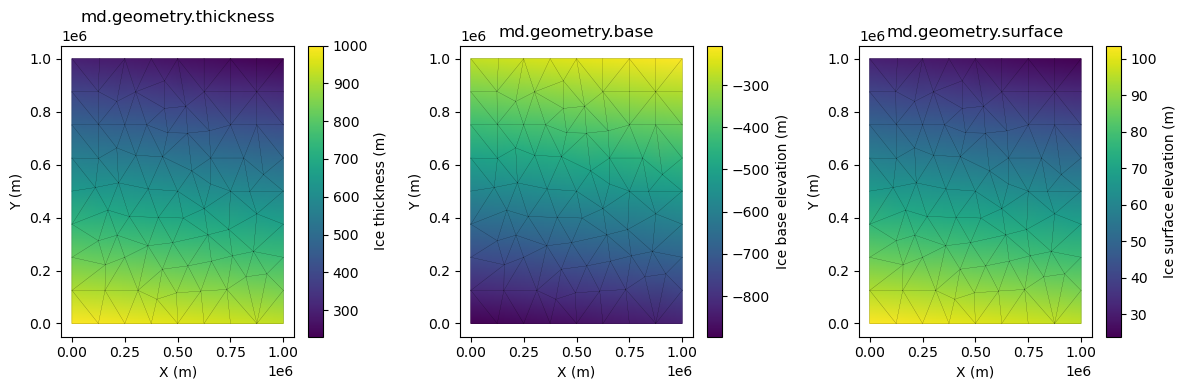

In [6]:
import matplotlib.pyplot as plt
# Visualise the model geometry
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

## Ice thickness
pyissm.plot.plot_model_field(md,
                             md.geometry.thickness,
                             show_cbar = True,
                             show_mesh = True,
                             ax = ax1,
                             cbar_kwargs = {'label': 'Ice thickness (m)'})
ax1.set_title('md.geometry.thickness')

## Ice base
pyissm.plot.plot_model_field(md,
                             md.geometry.base,
                             show_cbar = True,
                             show_mesh = True,
                             ax = ax2,
                             cbar_kwargs = {'label': 'Ice base elevation (m)'})
ax2.set_title('md.geometry.base')

## Ice surface
pyissm.plot.plot_model_field(md,
                             md.geometry.surface,
                             show_cbar = True,
                             show_mesh = True,
                             ax = ax3,
                             cbar_kwargs = {'label': 'Ice surface elevation (m)'})
ax3.set_title('md.geometry.surface')

plt.tight_layout()

In [12]:
# View a summary of the model solution
pyissm.tools.general.summarize_solution(md.results.TransientSolution[1])

Field                               Type                 Shape / Length
---------------------------------------------------------------------------
step                                int32                scalar
time                                float64              scalar
SmbMassBalance                      ndarray              (91,)
Vx                                  ndarray              (91,)
Vy                                  ndarray              (91,)
Vel                                 ndarray              (91,)
Pressure                            ndarray              (91,)
Thickness                           ndarray              (91,)
Surface                             ndarray              (91,)
Base                                ndarray              (91,)


Text(0.5, 1.0, 'Square Ice Shelf Velocity Field')

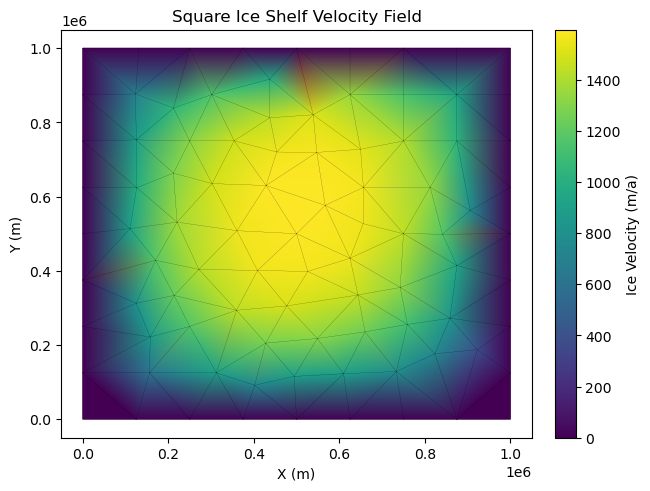

In [14]:
# Visualise the resultant velocity field
fig, ax = pyissm.plot.plot_model_field(md,
                                       field = md.results.TransientSolution[1].Vel,
                                       show_cbar = True,
                                       cbar_kwargs={'label': 'Ice Velocity (m/a)'},
                                       show_mesh = True)
ax.set_title('Square Ice Shelf Velocity Field')